# 第39篇｜一元线性回归：从散点图到预测方程

> 这是「数据分析从入门到精通」系列的第 39 篇，也是回归分析阶段的开篇。统计学打好了底子，这篇来迈出预测建模的第一步——一元线性回归。从散点图直观感受变量关系，到推导出预测方程，原理和代码一起上。

---

嗨，我是小荷～

第四阶段开始了！这个阶段叫**回归分析**。

之前我们学的是"描述数据""检验差异"——而回归分析是"**建立预测关系**"：根据已知变量，预测未知结果。

广告投入多少会带来多少销售额？房子面积多大对应多少房价？——这类问题，就需要回归。

今天从最简单的**一元线性回归**入手。

---

## 一、线性回归是什么？

一元线性回归就是用一条直线来描述两个变量之间的关系：


In [ ]:
y = β₀ + β₁x + ε


- y：因变量（被预测的）
- x：自变量（用来预测的）
- β₀：截距（x=0 时 y 的值）
- β₁：斜率（x 增加 1 个单位，y 变化多少）
- ε：误差项（无法被 x 解释的随机波动）

**目标**：找到最佳的 β₀ 和 β₁，使预测值尽量接近真实值。

---

## 二、从散点图到直线

散点图用于展示两个变量的关系，来画一个：


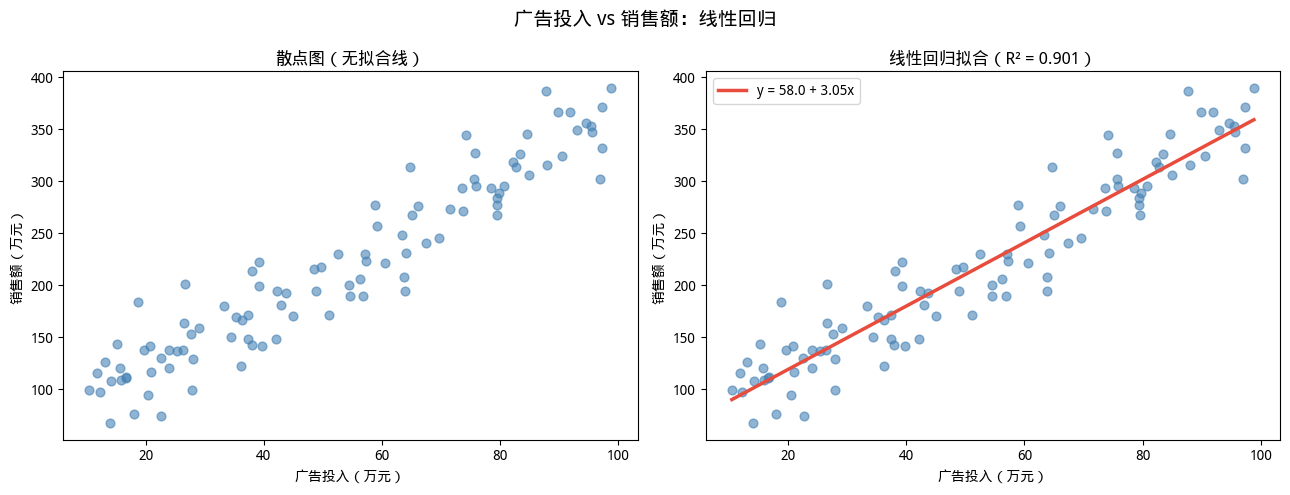

截距 β₀ = 57.99
斜率 β₁ = 3.05  （广告投入每增加1万元，销售额增加 3.05 万元）
R²   = 0.9007
p 值 = 0.0000


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n = 100

# 数据：广告投入 vs 销售额
ad_spend = np.random.uniform(10, 100, n)
sales    = 50 + 3.2 * ad_spend + np.random.normal(0, 30, n)

df = pd.DataFrame({'广告投入（万元）': ad_spend, '销售额（万元）': sales})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 散点图（无拟合线）
axes[0].scatter(ad_spend, sales, alpha=0.6, color='steelblue', s=40)
axes[0].set_title('散点图（无拟合线）', fontweight='bold')
axes[0].set_xlabel('广告投入（万元）')
axes[0].set_ylabel('销售额（万元）')

# 散点图（有拟合线）
slope, intercept, r_value, p_value, std_err = stats.linregress(ad_spend, sales)
x_line = np.linspace(ad_spend.min(), ad_spend.max(), 100)
y_line = intercept + slope * x_line

axes[1].scatter(ad_spend, sales, alpha=0.6, color='steelblue', s=40)
axes[1].plot(x_line, y_line, color='#E74C3C', linewidth=2.5,
              label=f'y = {intercept:.1f} + {slope:.2f}x')
axes[1].set_title(f'线性回归拟合（R² = {r_value**2:.3f}）', fontweight='bold')
axes[1].set_xlabel('广告投入（万元）')
axes[1].set_ylabel('销售额（万元）')
axes[1].legend(fontsize=10)

plt.suptitle('广告投入 vs 销售额：线性回归', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"截距 β₀ = {intercept:.2f}")
print(f"斜率 β₁ = {slope:.2f}  （广告投入每增加1万元，销售额增加 {slope:.2f} 万元）")
print(f"R²   = {r_value**2:.4f}")
print(f"p 值 = {p_value:.4f}")


---

## 三、最小二乘法（直觉版）

回归线是怎么找到的？答案是**最小二乘法**：找一条直线，使所有数据点到这条线的垂直距离（残差）的平方和最小。


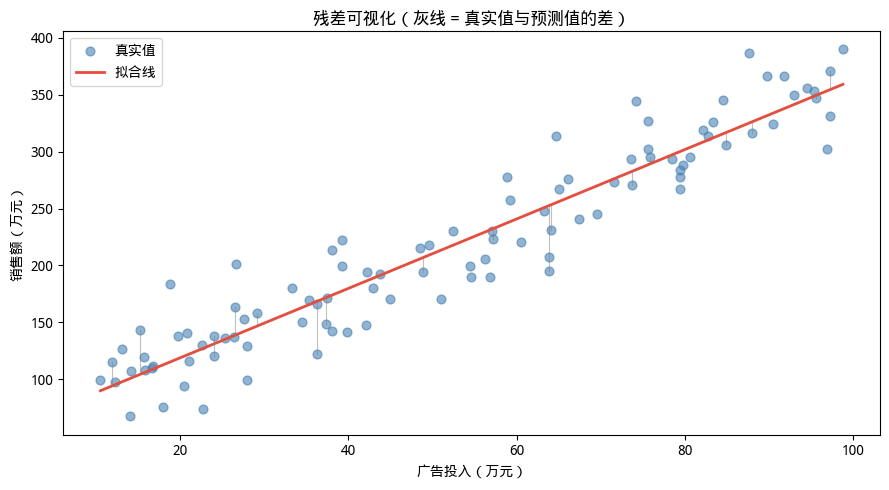

残差均值：0.0000（应接近 0）
残差标准差：26.94


In [3]:
# 可视化残差
fig, ax = plt.subplots(figsize=(9, 5))
y_pred = intercept + slope * ad_spend

ax.scatter(ad_spend, sales, alpha=0.6, color='steelblue', s=40, label='真实值')
ax.plot(x_line, y_line, color='#E74C3C', linewidth=2, label='拟合线')

# 画残差线
for xi, yi, ypi in zip(ad_spend[:20], sales[:20], y_pred[:20]):
    ax.plot([xi, xi], [yi, ypi], color='gray', linewidth=0.8, alpha=0.5)

ax.set_title('残差可视化（灰线 = 真实值与预测值的差）', fontweight='bold')
ax.legend()
ax.set_xlabel('广告投入（万元）')
ax.set_ylabel('销售额（万元）')
plt.tight_layout()
plt.show()

# 残差统计
residuals = sales - y_pred
print(f"残差均值：{residuals.mean():.4f}（应接近 0）")
print(f"残差标准差：{residuals.std():.2f}")


---

## 四、用 scikit-learn 做线性回归

来用代码实现线性回归：


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = ad_spend.reshape(-1, 1)   # sklearn 要求 2D 输入
y = sales

model = LinearRegression()
model.fit(X, y)

print("sklearn 线性回归结果：")
print(f"截距：{model.intercept_:.2f}")
print(f"斜率：{model.coef_[0]:.2f}")

# 预测
y_pred_sk = model.predict(X)
r2  = r2_score(y, y_pred_sk)
mse = mean_squared_error(y, y_pred_sk)
rmse = np.sqrt(mse)
print(f"\n模型评估：")
print(f"R²    = {r2:.4f}")
print(f"MSE   = {mse:.2f}")
print(f"RMSE  = {rmse:.2f}  （平均预测误差约 ±¥{rmse:.0f}万）")

# 预测新数据
new_spend = np.array([[30], [60], [90]])
pred = model.predict(new_spend)
for s, p in zip(new_spend.flatten(), pred):
    print(f"广告投入 {s} 万 → 预测销售额 {p:.1f} 万")


sklearn 线性回归结果：
截距：57.99
斜率：3.05

模型评估：
R²    = 0.9007
MSE   = 725.93
RMSE  = 26.94  （平均预测误差约 ±¥27万）
广告投入 30 万 → 预测销售额 149.4 万
广告投入 60 万 → 预测销售额 240.8 万
广告投入 90 万 → 预测销售额 332.2 万


---

## 五、用 statsmodels 获得完整统计输出

sklearn 只给系数和 R²，想要完整的统计报告就用 statsmodels：


In [5]:
import statsmodels.api as sm

# 添加常数项（截距）
X_sm = sm.add_constant(ad_spend)

model_sm = sm.OLS(sales, X_sm).fit()
print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     889.3
Date:                Wed, 20 May 2026   Prob (F-statistic):           5.87e-51
Time:                        19:11:45   Log-Likelihood:                -471.27
No. Observations:                 100   AIC:                             946.5
Df Residuals:                      98   BIC:                             951.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.9855      5.998      9.668      0.0

`summary()` 输出的关键内容：
- **coef**：截距和斜率的估计值
- **std err**：系数的标准误
- **t / P>|t|**：t 统计量和 p 值（判断系数是否显著）
- **R-squared**：R² 值
- **F-statistic**：整体模型的 F 检验

---

## 六、R² 的含义

R²（决定系数）= 模型能解释的方差比例：


In [6]:
# R² 可视化
ss_tot = np.sum((sales - sales.mean()) ** 2)
ss_res = np.sum((sales - y_pred) ** 2)
r2_manual = 1 - ss_res / ss_tot

print(f"总方差（SS_tot）= {ss_tot:.0f}")
print(f"残差方差（SS_res）= {ss_res:.0f}")
print(f"R² = 1 - SS_res/SS_tot = {r2_manual:.4f}")
print(f"含义：广告投入可以解释销售额 {r2_manual*100:.1f}% 的变异")


总方差（SS_tot）= 731364
残差方差（SS_res）= 72593
R² = 1 - SS_res/SS_tot = 0.9007
含义：广告投入可以解释销售额 90.1% 的变异


R² = 0.7 意味着：70% 的销售额变动能被广告投入解释，还有 30% 是其他因素（品牌、季节等）导致的。

---

## 七、🔧 综合实战：预测城市销售额

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


模型性能：
训练集 R² = 0.9715
测试集 R² = 0.9584
测试集 MAE = 657.8 亿元


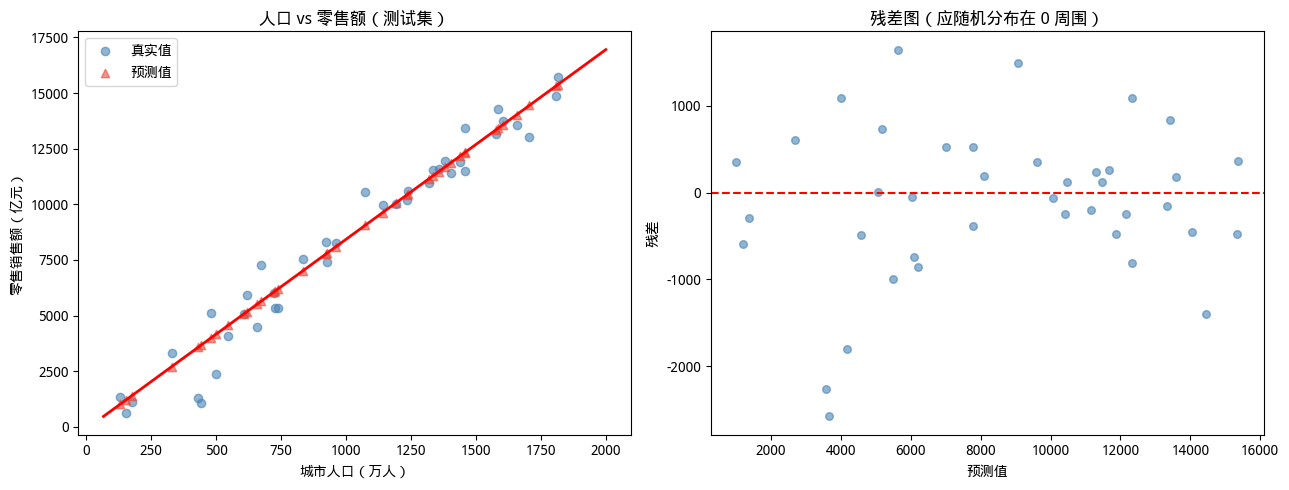


模型方程：零售额 = -99.5 + 8.53 × 人口（万人）


In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2024)
n = 200

# 构造数据：人口 vs 零售额
population = np.random.uniform(50, 2000, n)     # 万人
retail_sales = 8.5 * population + np.random.normal(0, 800, n)  # 亿元

# 划分训练集测试集
X = population.reshape(-1, 1)
y = retail_sales

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练
model = LinearRegression()
model.fit(X_train, y_train)

# 评估
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("模型性能：")
print(f"训练集 R² = {r2_score(y_train, y_pred_train):.4f}")
print(f"测试集 R² = {r2_score(y_test, y_pred_test):.4f}")
print(f"测试集 MAE = {mean_absolute_error(y_test, y_pred_test):.1f} 亿元")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_test, y_test, alpha=0.6, color='steelblue', label='真实值')
axes[0].scatter(X_test, y_pred_test, alpha=0.6, color='#E74C3C', marker='^', label='预测值')
x_full = np.linspace(population.min(), population.max(), 100).reshape(-1, 1)
axes[0].plot(x_full, model.predict(x_full), 'r-', linewidth=2)
axes[0].set_title('人口 vs 零售额（测试集）', fontweight='bold')
axes[0].set_xlabel('城市人口（万人）')
axes[0].set_ylabel('零售销售额（亿元）')
axes[0].legend()

# 残差图
residuals_test = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals_test, alpha=0.6, color='steelblue', s=30)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('残差图（应随机分布在 0 周围）', fontweight='bold')
axes[1].set_xlabel('预测值')
axes[1].set_ylabel('残差')

plt.tight_layout()
plt.show()

print(f"\n模型方程：零售额 = {model.intercept_:.1f} + {model.coef_[0]:.2f} × 人口（万人）")


---

## 八、📋 一元线性回归速查

| 步骤 | 代码 |
|------|------|
| 拟合模型 | `model = LinearRegression(); model.fit(X, y)` |
| 查看系数 | `model.intercept_`, `model.coef_` |
| 预测 | `model.predict(X_new)` |
| 评估 R² | `r2_score(y, y_pred)` |
| 评估误差 | `mean_squared_error`, `mean_absolute_error` |
| 完整统计输出 | `statsmodels OLS` |

---

## 九、📝 小结

一元线性回归要点：
1. **目标**：找到最佳的截距和斜率，最小化残差平方和
2. **R²**：模型解释了多少方差，越接近 1 越好
3. **p 值**：系数是否显著（p < 0.05 才可信）
4. **残差图**：残差应随机分布，无规律 → 模型假设合理

---

## 十、🏋️ 课后练习

1. 用广告投入和销售额数据，训练一元线性回归，预测"广告投入 50 万时的销售额"。
2. 画残差图，判断残差是否随机分布（是则模型假设成立）。
3. 分别用 R² 和 RMSE 评估模型，说说这个模型的实际意义。

练习1：用广告投入和销售额数据，训练一元线性回归，预测广告投入 50 万时的销售额。

数据预览（前10行）：
 ad_spend      sales
10.000000  89.934283
10.909091  79.961987
11.818182  98.408316
12.727273 118.642415
13.636364  86.226023
14.545455  88.953624
15.454545 127.947893
16.363636 114.439604
17.272727  92.428694
18.181818 115.396655

数据统计信息：
广告投入范围: 10.00 - 100.00 万元
销售额范围: 77.19 - 349.77 万元
相关系数: 0.9752

线性回归模型参数：
截距 (β₀): 46.1272
斜率 (β₁): 3.0269
预测方程: y = 3.0269 * x + 46.1272

预测结果：
广告投入 50 万元时的预测销售额: 197.47 万元


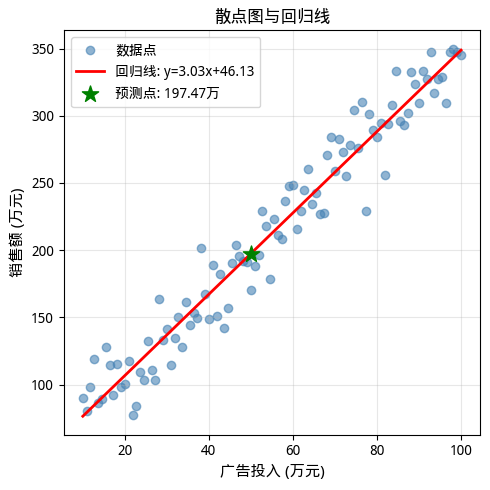

In [10]:
print("练习1：用广告投入和销售额数据，训练一元线性回归，预测广告投入 50 万时的销售额。")

# 构造模拟数据：ad_spend从10到100，sales = 3*ad_spend + 随机噪声
np.random.seed(42)  # 设置随机种子以保证可重复性
n_samples = 100
ad_spend = np.linspace(10, 100, n_samples)  # 广告投入从10到100万
noise = np.random.normal(0, 20, n_samples)  # 随机噪声
sales = 3 * ad_spend + 50 + noise  # 销售额 = 3*广告投入 + 截距 + 噪声

# 创建数据框
df = pd.DataFrame({
    'ad_spend': ad_spend,
    'sales': sales
})

print("\n数据预览（前10行）：")
print(df.head(10).to_string(index=False))

print(f"\n数据统计信息：")
print(f"广告投入范围: {ad_spend.min():.2f} - {ad_spend.max():.2f} 万元")
print(f"销售额范围: {sales.min():.2f} - {sales.max():.2f} 万元")
print(f"相关系数: {np.corrcoef(ad_spend, sales)[0, 1]:.4f}")

# 划分训练集和测试集
X = df[['ad_spend']]
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练线性回归模型
model = LinearRegression()
model.fit(X_train.values, y_train)

# 获取模型参数
beta_0 = model.intercept_  # 截距
beta_1 = model.coef_[0]   # 斜率

print(f"\n线性回归模型参数：")
print(f"截距 (β₀): {beta_0:.4f}")
print(f"斜率 (β₁): {beta_1:.4f}")
print(f"预测方程: y = {beta_1:.4f} * x + {beta_0:.4f}")

# 预测广告投入50万时的销售额
# 明确构建一个带有相同列名的 DataFrame 进行预测
sales_pred_50 = model.predict([[50]])[0]
print(f"\n预测结果：")
print(f"广告投入 50 万元时的预测销售额: {sales_pred_50:.2f} 万元")

# 可视化 散点图 + 回归线
fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))
ax1.scatter(ad_spend, sales, alpha=0.6, label='数据点', color='steelblue')
x_line = np.linspace(ad_spend.min(), ad_spend.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax1.plot(x_line, y_line, color='red', linewidth=2, label=f'回归线: y={beta_1:.2f}x+{beta_0:.2f}')
ax1.scatter([50], [sales_pred_50], color='green', s=150, zorder=5, marker='*', label=f'预测点: {sales_pred_50:.2f}万')
ax1.set_xlabel('广告投入 (万元)', fontsize=11)
ax1.set_ylabel('销售额 (万元)', fontsize=11)
ax1.set_title('散点图与回归线', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

练习2：画残差图，判断残差是否随机分布（是则模型假设成立）。

残差统计（测试集）：
残差均值: 1.5948
残差标准差: 16.1008
残差最大值: 39.8931
残差最小值: -27.0403
残差均值偏离0，可能存在系统偏差


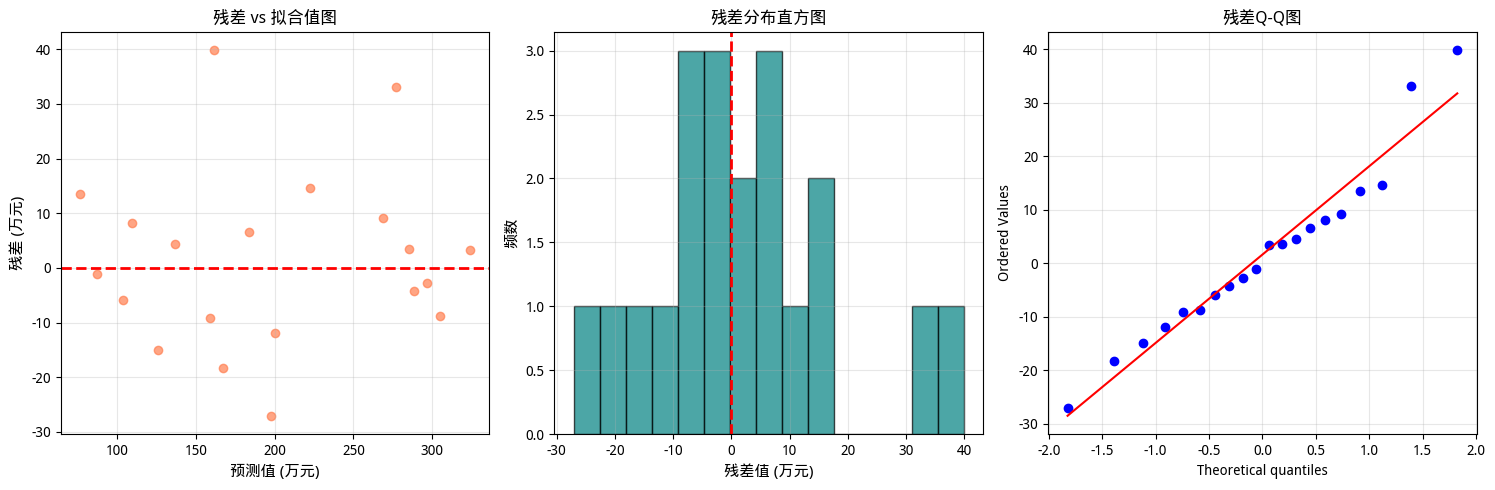

In [13]:
print("练习2：画残差图，判断残差是否随机分布（是则模型假设成立）。")

# 计算预测值和残差
y_pred = model.predict(X_test.values)
residuals = y_test - y_pred

# 计算训练集的残差
y_train_pred = model.predict(X_train.values)
train_residuals = y_train - y_train_pred

print("\n残差统计（测试集）：")
print(f"残差均值: {residuals.mean():.4f}")
print(f"残差标准差: {residuals.std():.4f}")
print(f"残差最大值: {residuals.max():.4f}")
print(f"残差最小值: {residuals.min():.4f}")

# 判断残差是否随机分布（接近0为随机）
if abs(residuals.mean()) < 1:
    print("残差均值接近0，残差呈随机分布 ✓")
else:
    print("残差均值偏离0，可能存在系统偏差")

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 图2：残差 vs 拟合值（测试集）
ax2 = axes[0]
ax2.scatter(y_pred, residuals, alpha=0.7, color='coral')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('预测值 (万元)', fontsize=11)
ax2.set_ylabel('残差 (万元)', fontsize=11)
ax2.set_title('残差 vs 拟合值图', fontsize=12)
ax2.grid(True, alpha=0.3)

# 图3：残差直方图
ax3 = axes[1]
ax3.hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='teal')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('残差值 (万元)', fontsize=11)
ax3.set_ylabel('频数', fontsize=11)
ax3.set_title('残差分布直方图', fontsize=12)
ax3.grid(True, alpha=0.3)

# 图4：Q-Q图检验残差正态性
ax4 = axes[2]
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('残差Q-Q图', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
print("3. 分别用 R² 和 RMSE 评估模型，说说这个模型的实际意义。")
print("-" * 50)

# 计算评估指标
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n模型性能评估：")
print("-" * 30)
print(f"训练集 R²: {r2_train:.4f}")
print(f"测试集 R²: {r2_test:.4f}")
print(f"训练集 RMSE: {rmse_train:.4f}")
print(f"测试集 RMSE: {rmse_test:.4f}")

print("\nR² 解释：")
print(f"R² = {r2_test:.4f} 表示模型解释了 {r2_test*100:.2f}% 的销售额变异")
print(f"RMSE = {rmse_test:.4f} 万元表示预测的平均误差")

3. 分别用 R² 和 RMSE 评估模型，说说这个模型的实际意义。
--------------------------------------------------

模型性能评估：
------------------------------
训练集 R²: 0.9481
测试集 R²: 0.9613
训练集 RMSE: 18.5846
测试集 RMSE: 15.7739

R² 解释：
R² = 0.9613 表示模型解释了 96.13% 的销售额变异
RMSE = 15.7739 万元表示预测的平均误差


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 40 篇：最小二乘法原理 — 模型是怎么拟合的**
>
> 下篇来学最小二乘法原理——手推一次线性回归，看清楚系数是怎么算出来的，彻底理解线性回归的数学本质。

---

*跟着小荷，数据分析路上不迷路～*